In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

IMG_SIZE = (224, 224)
NUM_CLASSES = 5
CLASS_NAMES = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

MODEL_PATH = "stage1_efficientnet_tabular.keras"
X_NODES_PATH = "X_nodes_embeddings.npy"
EDGE_INDEX_PATH = "edge_index_patient_graph.npy"
Y_PATH = "y_all_graph.npy"
GRAPH_DF_PATH = "graph_patient_dataframe.csv"
GAT_WEIGHTS_PATH = "patient_similarity_gat.weights.h5"

stage1_model = tf.keras.models.load_model(     MODEL_PATH,     compile=False,     safe_mode=False )
X_nodes_np = np.load(X_NODES_PATH).astype("float32")
edge_index_np = np.load(EDGE_INDEX_PATH).astype("int32")
y_all_np = np.load(Y_PATH).astype("int32")
graph_df = pd.read_csv(GRAPH_DF_PATH)

X_nodes = tf.constant(X_nodes_np, dtype=tf.float32)
edge_index = tf.constant(edge_index_np, dtype=tf.int32)

print("Loaded stage1 model:", stage1_model.name)
print("X_nodes:", X_nodes_np.shape)
print("edge_index:", edge_index_np.shape)
print("graph_df:", graph_df.shape)


2026-05-12 12:52:26.486561: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 12:52:26.556708: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 12:52:26.556767: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 12:52:26.557830: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 12:52:26.557905: I external/local_xla/xla/stream_executor

Loaded stage1 model: Stage1_EfficientNet_Tabular
X_nodes: (7612, 521)
edge_index: (2, 71890)
graph_df: (7612, 14)


In [5]:
class GraphAttentionLayer(tf.keras.layers.Layer):
    def __init__(self, out_dim, dropout_rate=0.2, alpha=0.2, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.dropout_rate = dropout_rate
        self.alpha = alpha
        self.leaky_relu = tf.keras.layers.LeakyReLU(alpha=alpha)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)

    def build(self, input_shape):
        feature_dim = int(input_shape[0][-1])
        self.W = self.add_weight(shape=(feature_dim, self.out_dim), initializer="glorot_uniform", trainable=True, name="W")
        self.a_src = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_src")
        self.a_dst = self.add_weight(shape=(self.out_dim, 1), initializer="glorot_uniform", trainable=True, name="a_dst")

    def call(self, inputs, training=False, return_attention=False):
        X, edge_index = inputs
        src = edge_index[0]
        dst = edge_index[1]

        H = tf.matmul(X, self.W)
        H_src = tf.gather(H, src)
        H_dst = tf.gather(H, dst)

        e = self.leaky_relu(tf.matmul(H_src, self.a_src) + tf.matmul(H_dst, self.a_dst))
        e = tf.squeeze(e, axis=-1)

        num_nodes = tf.shape(X)[0]
        max_per_dst = tf.math.unsorted_segment_max(e, dst, num_segments=num_nodes)
        e_exp = tf.exp(e - tf.gather(max_per_dst, dst))
        denom = tf.math.unsorted_segment_sum(e_exp, dst, num_segments=num_nodes)
        attention = e_exp / (tf.gather(denom, dst) + 1e-9)
        attention = self.dropout(attention, training=training)

        messages = H_src * tf.expand_dims(attention, axis=-1)
        out = tf.math.unsorted_segment_sum(messages, dst, num_segments=num_nodes)

        if return_attention:
            return out, attention
        return out


class MultiHeadGAT(tf.keras.layers.Layer):
    def __init__(self, out_dim, num_heads=4, concat=True, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.heads = [
            GraphAttentionLayer(out_dim=out_dim, dropout_rate=dropout_rate, name=f"gat_head_{i}")
            for i in range(num_heads)
        ]
        self.concat = concat

    def call(self, inputs, training=False):
        outputs = [head(inputs, training=training) for head in self.heads]
        if self.concat:
            return tf.concat(outputs, axis=-1)
        return tf.reduce_mean(tf.stack(outputs, axis=0), axis=0)


class PatientGATModel(tf.keras.Model):
    def __init__(self, hidden_dim=64, num_heads=4, num_classes=5, dropout_rate=0.25):
        super().__init__()
        self.input_dense = tf.keras.layers.Dense(160, activation="relu")
        self.input_dropout = tf.keras.layers.Dropout(dropout_rate)
        self.gat1 = MultiHeadGAT(out_dim=hidden_dim, num_heads=num_heads, concat=True, dropout_rate=dropout_rate)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.gat2 = GraphAttentionLayer(out_dim=hidden_dim, dropout_rate=dropout_rate)
        self.bn2 = tf.keras.layers.BatchNormalization()
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)
        self.classifier_hidden = tf.keras.layers.Dense(64, activation="relu")
        self.classifier_dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax", name="dr_icdr_classifier")

    def call(self, inputs, training=False):
        X, edge_index = inputs
        x = self.input_dense(X)
        x = self.input_dropout(x, training=training)
        x = self.gat1([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn1(x, training=training)
        x = self.dropout1(x, training=training)
        x = self.gat2([x, edge_index], training=training)
        x = tf.nn.elu(x)
        x = self.bn2(x, training=training)
        x = self.dropout2(x, training=training)
        x = self.classifier_hidden(x)
        x = self.classifier_dropout(x, training=training)
        return self.classifier(x)


gat_model = PatientGATModel(hidden_dim=64, num_heads=4, num_classes=NUM_CLASSES, dropout_rate=0.25)
_ = gat_model([X_nodes, edge_index], training=False)
gat_model.load_weights(GAT_WEIGHTS_PATH)

gat_probs = gat_model([X_nodes, edge_index], training=False).numpy()
gat_preds = np.argmax(gat_probs, axis=1)

print("Loaded GAT weights")
print("GAT prediction shape:", gat_probs.shape)

2026-05-12 12:52:54.142870: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Loaded GAT weights
GAT prediction shape: (7612, 5)


Using CNN layer: top_activation


2026-05-12 12:53:02.877670: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-12 12:53:03.139892: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Graph index: 6858
Patient ID: 20
True label: 0
GAT predicted: 4
GAT probabilities: [0.2046 0.1929 0.1702 0.1778 0.2545]


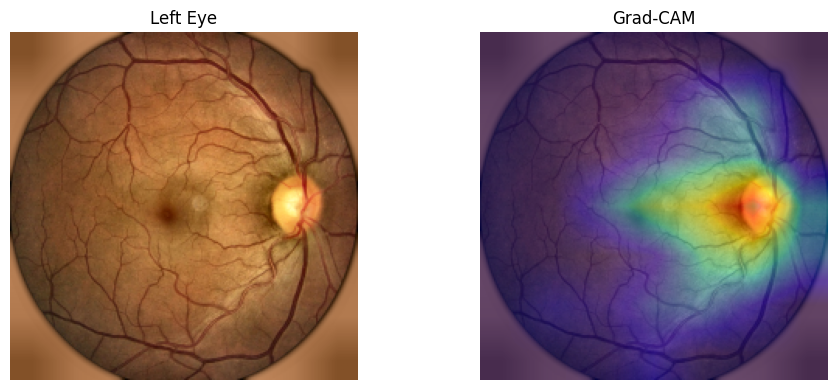

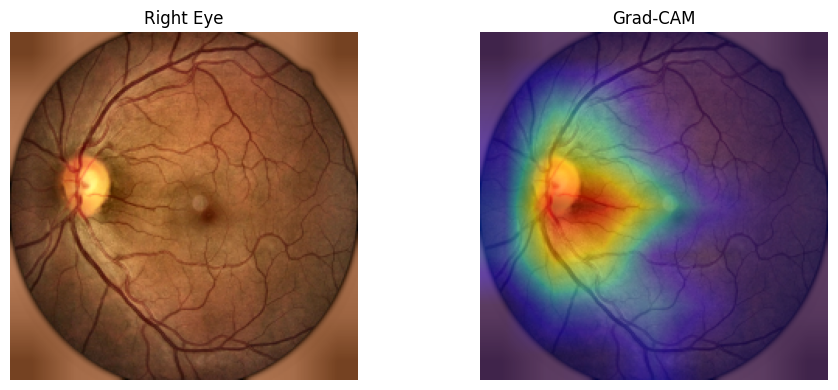

In [6]:
def load_image_np(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img.numpy()


image_encoder = stage1_model.get_layer("efficientnet_image_encoder")

base_model = None
for layer in image_encoder.layers:
    if "efficientnet" in layer.name.lower():
        base_model = layer
        break

last_conv_layer = None
for layer in reversed(base_model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer = layer
            break
    except:
        pass

grad_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

print("Using CNN layer:", last_conv_layer.name)


def make_gradcam(img_np):
    x = np.expand_dims(img_np, axis=0).astype("float32") * 255.0

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(x)
        score = tf.reduce_mean(features)

    grads = tape.gradient(score, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1, 2))

    cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)
    cam = tf.nn.relu(cam)[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    cam = tf.image.resize(cam[..., None], IMG_SIZE).numpy().squeeze()
    return cam


def show_gradcam(img_np, cam, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


selected_idx = np.where(graph_df["split"].values == "test")[0][0]
patient = graph_df.iloc[selected_idx]

left_img = load_image_np(patient["left_image_path"])
right_img = load_image_np(patient["right_image_path"])

left_cam = make_gradcam(left_img)
right_cam = make_gradcam(right_img)

print("Graph index:", selected_idx)
print("Patient ID:", patient["patient_id"])
print("True label:", int(y_all_np[selected_idx]))
print("GAT predicted:", int(gat_preds[selected_idx]))
print("GAT probabilities:", np.round(gat_probs[selected_idx], 4))

show_gradcam(left_img, left_cam, "Left Eye")
show_gradcam(right_img, right_cam, "Right Eye")

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


  0%|          | 0/1 [00:00<?, ?it/s]

Explaining graph index: 6858
Predicted class: 4 Class 4


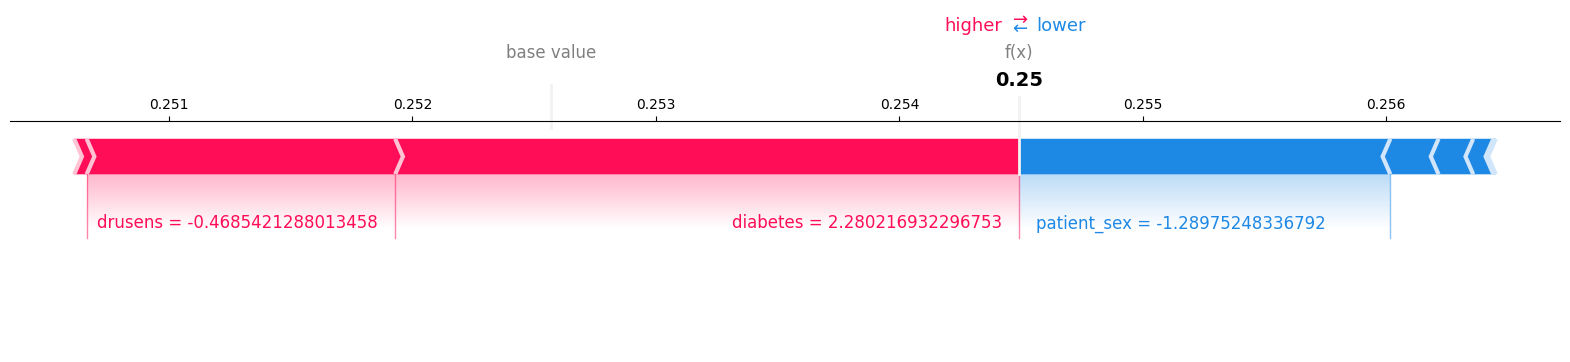

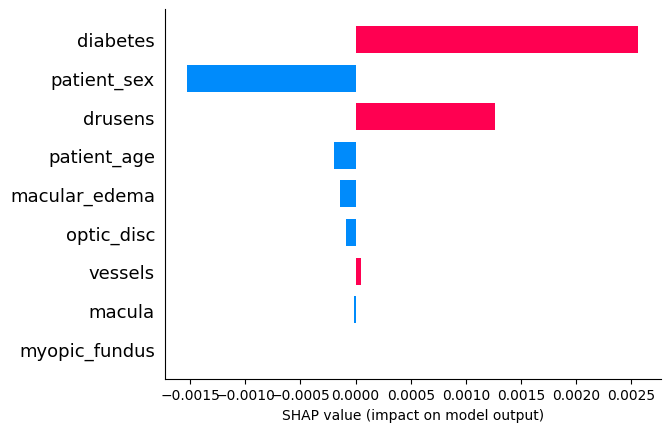

In [7]:
import shap

tabular_features = [
    "patient_age",
    "patient_sex",
    "diabetes",
    "optic_disc",
    "vessels",
    "macula",
    "macular_edema",
    "drusens",
    "myopic_fundus"
]

tab_start = X_nodes_np.shape[1] - len(tabular_features)
X_tab_nodes = X_nodes_np[:, tab_start:]

selected_idx = np.where(graph_df["split"].values == "test")[0][0]
pred_class = int(gat_preds[selected_idx])

background_idx = np.random.choice(len(X_tab_nodes), size=min(50, len(X_tab_nodes)), replace=False)
background_tab = X_tab_nodes[background_idx]

fixed_X_nodes = X_nodes_np.copy()

def predict_from_tabular(tab_values):
    outputs = []
    for row in tab_values:
        temp_X = fixed_X_nodes.copy()
        temp_X[selected_idx, tab_start:] = row
        prob = gat_model(
            [tf.constant(temp_X, dtype=tf.float32), edge_index],
            training=False
        ).numpy()[selected_idx]
        outputs.append(prob)
    return np.array(outputs)

explainer = shap.KernelExplainer(predict_from_tabular, background_tab)
shap_values = explainer.shap_values(X_tab_nodes[selected_idx:selected_idx+1], nsamples=100)

print("Explaining graph index:", selected_idx)
print("Predicted class:", pred_class, CLASS_NAMES[pred_class])

shap.force_plot(
    explainer.expected_value[pred_class],
    shap_values[pred_class][0],
    X_tab_nodes[selected_idx],
    feature_names=tabular_features,
    matplotlib=True
)
plt.show()

shap.bar_plot(
    shap_values[pred_class][0],
    feature_names=tabular_features,
    max_display=len(tabular_features)
)
plt.show()

In [8]:
selected_idx = np.where(graph_df["split"].values == "test")[0][0]
patient = graph_df.iloc[selected_idx]

x0 = gat_model.input_dense(X_nodes)
x0 = gat_model.gat1([x0, edge_index], training=False)
x0 = tf.nn.elu(x0)
x0 = gat_model.bn1(x0, training=False)

gat2_out, attention_scores = gat_model.gat2(
    [x0, edge_index],
    training=False,
    return_attention=True
)

attention_scores_np = attention_scores.numpy()
src_np = edge_index_np[0]
dst_np = edge_index_np[1]

incoming_mask = dst_np == selected_idx
incoming_sources = src_np[incoming_mask]
incoming_attention = attention_scores_np[incoming_mask]

top_order = np.argsort(incoming_attention)[-10:][::-1]

attention_rows = []
for rank, pos in enumerate(top_order, start=1):
    neighbor_idx = int(incoming_sources[pos])
    row = graph_df.iloc[neighbor_idx]

    attention_rows.append({
        "rank": rank,
        "neighbor_graph_idx": neighbor_idx,
        "neighbor_patient_id": row["patient_id"],
        "split": row["split"],
        "neighbor_true_label": int(y_all_np[neighbor_idx]),
        "neighbor_pred_label": int(gat_preds[neighbor_idx]),
        "attention_score": float(incoming_attention[pos])
    })

attention_df = pd.DataFrame(attention_rows)

print("Selected patient")
print("Graph index:", selected_idx)
print("Patient ID:", patient["patient_id"])
print("True label:", int(y_all_np[selected_idx]))
print("Predicted label:", int(gat_preds[selected_idx]))
print("Prediction probabilities:", np.round(gat_probs[selected_idx], 4))

display(attention_df)

Selected patient
Graph index: 6858
Patient ID: 20
True label: 0
Predicted label: 4
Prediction probabilities: [0.2046 0.1929 0.1702 0.1778 0.2545]


,rank,neighbor_graph_idx,neighbor_patient_id,split,neighbor_true_label,neighbor_pred_label,attention_score
0,1,6109,108,val,1,4,0.127043
1,2,68,93,train,0,4,0.126461
2,3,6871,132,test,0,4,0.126312
3,4,6858,20,test,0,4,0.124718
4,5,6104,81,val,1,4,0.124580
5,6,6111,119,val,0,4,0.124249
6,7,6083,8511,train,1,4,0.124178
7,8,74,105,train,0,4,0.122459


In [9]:
def explain_patient_full_visual(selected_idx):
    patient = graph_df.iloc[selected_idx]

    left_img = load_image_np(patient["left_image_path"])
    right_img = load_image_np(patient["right_image_path"])

    left_cam = make_gradcam(left_img)
    right_cam = make_gradcam(right_img)

    pred_class = int(gat_preds[selected_idx])
    true_class = int(y_all_np[selected_idx])

    shap_values = explainer.shap_values(
        X_tab_nodes[selected_idx:selected_idx+1],
        nsamples=100
    )

    shap_for_class = shap_values[pred_class][0]

    tabular_data = pd.DataFrame({
        "Feature": tabular_features,
        "Value": X_tab_nodes[selected_idx],
        "SHAP": shap_for_class
    })

    tabular_data = tabular_data.sort_values(
        by="SHAP",
        key=abs,
        ascending=False
    )

    fig = plt.figure(figsize=(18, 10))

    ax1 = plt.subplot(2, 3, 1)
    ax1.imshow(left_img)
    ax1.set_title("Left Eye Fundus")
    ax1.axis("off")

    ax2 = plt.subplot(2, 3, 2)
    ax2.imshow(left_img)
    ax2.imshow(left_cam, cmap="jet", alpha=0.45)
    ax2.set_title("Left Eye Grad-CAM")
    ax2.axis("off")

    ax3 = plt.subplot(2, 3, 3)
    ax3.axis("off")
    table = ax3.table(
        cellText=tabular_data[["Feature", "Value"]].round(3).values,
        colLabels=["Feature", "Value"],
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.4)
    ax3.set_title("Patient Tabular Data")

    ax4 = plt.subplot(2, 3, 4)
    ax4.imshow(right_img)
    ax4.set_title("Right Eye Fundus")
    ax4.axis("off")

    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(right_img)
    ax5.imshow(right_cam, cmap="jet", alpha=0.45)
    ax5.set_title("Right Eye Grad-CAM")
    ax5.axis("off")

    ax6 = plt.subplot(2, 3, 6)
    ax6.barh(tabular_data["Feature"], tabular_data["SHAP"])
    ax6.axvline(0, color="black", linewidth=1)
    ax6.set_title(f"SHAP Explanation for Predicted Class {pred_class}")
    ax6.set_xlabel("SHAP value")
    ax6.invert_yaxis()

    plt.suptitle(
        f"Patient ID: {patient['patient_id']} | True: {true_class} | Predicted: {pred_class}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

    return tabular_data

In [11]:
selected_idx = np.where(graph_df["split"].values == "test")[0][5]

tabular_explanation = explain_patient_full_visual(selected_idx)
display(tabular_explanation)

  0%|          | 0/1 [00:00<?, ?it/s]

2026-05-12 13:06:14.440320: W external/local_tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.86MiB (rounded to 1948672)requested by op UnsortedSegmentSum
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-05-12 13:06:14.440562: I external/local_tsl/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2026-05-12 13:06:14.440592: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 150, Chunks in use: 144. 37.5KiB allocated for chunks. 36.0KiB in use in bin. 11.6KiB client-requested in use in bin.
2026-05-12 13:06:14.440604: I external/local_tsl/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 93, Chunks in use: 87. 58.0KiB allocated for chunks. 54.8KiB in use in bin. 44.2KiB client-requested in use in bin.
2026-05-12 

ResourceExhaustedError: Exception encountered when calling layer 'gat_head_2' (type GraphAttentionLayer).

{{function_node __wrapped__UnsortedSegmentSum_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[7612,64] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:UnsortedSegmentSum] name: 

Call arguments received by layer 'gat_head_2' (type GraphAttentionLayer):
  • inputs=['tf.Tensor(shape=(7612, 160), dtype=float32)', 'tf.Tensor(shape=(2, 71890), dtype=int32)']
  • training=False
  • return_attention=False